

---

# **Article Link**

---



https://www.pna.gov.ph/articles/1234579

## **Chartered flights eyed for repatriation of over 200 OFWs in Lebanon**
*By Ruth Abbey Gita-Carlos*

*October 2, 2024, 4:22 pm*

MANILA – The government is arranging chartered flights for the repatriation of more than 200 overseas Filipino workers in Beirut, Lebanon, the Department of Migrant Workers (DMW) said Wednesday.

“We are trying to provide for chartered flights. We’re talking to airline companies so that the chartered flights would be able to accommodate for example, no less than 300 overseas Filipino workers from Beirut,” DMW Undersecretary Bernard Olalia said in a Palace press briefing.

This was after the scheduled flights of around 15 OFWs on Sept. 25 were cancelled because of the recent bombings in Beirut.

Olalia said around 111 OFWs are staying in four temporary shelters in Beirut and waiting for their repatriation.

An additional 110 OFWs are applying for exit permits from the Lebanese government, Olalia said.

“Apart from the documented OFWs, we have undocumented OFWs who need to secure travel documents and once they’re given travel documents, we will help them in securing also exit visas or exit permits from the Immigration of the Lebanese government,” he said.

Olalia, however, said the Philippine government is facing several challenges, including securing landing rights for chartered flights.

He said land and sea routes are being considered, in case the situation escalates and makes it “impossible” to take the air route.

“The DMW is also studying the possibility of other routes. Apart from air route, we will be assessing the sea and the land route, should the case or the situation there worsen,” Olalia said.

He said the DMW, the Overseas Workers Welfare Administration (OWWA), and other concerned agencies will adopt a “whole-of-government assistance" upon the directive of President Ferdinand R. Marcos Jr.

He said each repatriated OFW will get PHP150,000 in financial assistance from the DMW and OWWA, as well as psychosocial services.

Israel has intensified its airstrikes across the northern border into Lebanon, targeting the Iran-backed militant group Hezbollah.

Iran fired ballistic missiles in Israel on Tuesday night, following the deadly attacks on Gaza and Lebanon and the recent killings of Hamas, Hezbollah, and Islamic Revolutionary Guard Corps leaders.

Olalia said no Filipinos were hurt since the attacks were launched.

“We have men on the ground. They work around the clock. At ‘yung mga staff po natin, dinagdagan na po natin (And we augmented our staff) both in Lebanon at (and) nearby posts to be able to provide safest route, to evacuate and ultimately to facilitate the repatriation of our OFWs both either in Lebanon or in Israel,” he said. (PNA)



---

# **Model Code Explanations**

---





---

## ***BERT Baseline Model***

---



In [ ]:
from transformers import pipeline, BertTokenizer, BertForQuestionAnswering
import textwrap

#Load the fine-tuned model
model = BertForQuestionAnswering.from_pretrained('deepset/bert-base-cased-squad2')
tokenizer = BertTokenizer.from_pretrained('deepset/bert-base-cased-squad2')

In the first section of the model, the relevant libraries are imported, and the fine-tuned BERT model is loaded. The pipeline function in the Hugging Face Transformers package serves as a user-friendly interface for downstream tasks, while BertTokenizer will convert the text into tokens that BERT can use.

BertForQuestionAnswering loads a BERT model that's fine-tuned for extractive question answering. The textwrap module is also imported to assist with formatting text.

Both the model and tokenizer are instantiated with from_pretrained('deepset/bert-base-cased-squad2'), which is a BERT model fine-tuned on SQuAD2.0, meaning it can extract text-based answers accurately from the passages.

In [ ]:
#Create a pipeline for question answering
qna_pipeline = pipeline('question-answering', model=model, tokenizer=tokenizer)

context = input("enter Context Article: ")
dedented_text = textwrap.dedent(context).strip()
print("Context Article:\n")
print(textwrap.fill(dedented_text, width=120))

The second section creates a pipeline for question answering by combining the model and tokenizer into a single object, which allows the user to perform the tokenization, prediction, and formatting of the output in one function. The user is then prompted to enter an article, which becomes the context for the pipeline. To ensure the article is readable, the raw text is cleaned using textwrap.dedent(), then .strip(), and is printed again using textwrap.fill() so that the article displays cleanly in the console.

In [ ]:
inquiry = input("\nType your question: ")
while (inquiry!='*'):
  answer = qna_pipeline({'question':inquiry, 'context': context})
  print("Answer found: "+answer ['answer'])
  print("At Index: ", answer ['start']," - ",answer ['end'])
  print("with probability:", answer['score'],"\n")
  inquiry = input("enter another question(* to stop):")

The third section creates a loop allowing users to create multiple questions about the article. Each question and context that is passed into the pipeline will evaluate and provide the predicted answer, text span where it exists, and confidence score. All of these will be printed to allow transparency. The loop will continue until the user inputs *, which allows for interactive exploration of the article without running the whole program again.



---


### ***Baseline Evaluation***

---



In [ ]:
import time
import pandas as pd

# Simple F1 function for token overlap
def compute_f1(pred, gold):
    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 3)


The initial cell sets up the environment for evaluation after doing interactive question answering. It imports time for timing how long each question takes to respond, and pandas for easily structuring the results into an easy to read table.

A helper function called, compute_f1, is defined to compute a token-level F1 score between the predicted answer and the gold answer. The function takes the two strings, converts them to lower case, and splits them into tokens. Each string is evaluated for precision and recall, while each of the two strings can be evaluated for overlap of tokens.

The F1 score provides a more flexible measure of partial correctness than exact match (EM), which is useful when if the predicted answer is correct semantically it's different just worded a little different.

In [ ]:
# Define questions + gold answers
questions = [
    "How many overseas Filipino workers are set for repatriation from Beirut?",
    "Who announced the plan for chartered flights for OFWs?",
    "Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?",
    "How many OFWs are currently staying in temporary shelters in Beirut?",
    "How many OFWs are applying for exit permits from the Lebanese government?",
    "What challenges does the Philippine government face in arranging chartered flights?",
    "What alternative routes are being considered aside from air travel?",
    "How much financial assistance will each repatriated OFW receive?",
    "Which militant group was targeted by Israel’s intensified airstrikes?",
    "Were any Filipinos hurt in the recent attacks?"
]

gold_answers = [
    "more than 200",          # Q1
    "Bernard Olalia",         # Q2
    "recent bombings",        # Q3
    "111",                    # Q4
    "110",                    # Q5
    "securing landing rights",# Q6
    "land and sea routes",    # Q7
    "PHP150,000",             # Q8
    "Hezbollah",              # Q9
    "No"                      # Q10
]


This sections lays out the evaluation set by presenting a series of questions and their associated gold answers. The purpose of the questions is to ascertain whether the model can pull the relevant information from the prompt. The gold answers will serve as the reference for determining correctness and will establish the basis for calculating EM and F1 scores. This arrangement allows us to assess the performance of the model in a manner that is coherent and systematic, allowing for both numerical comparison among questions and, later, across models compute sampling across other questions.

In [ ]:
# Collect results
results = []
for q, gold in zip(questions, gold_answers):
    start = time.time()
    answer = qna_pipeline({'question': q, 'context': context})
    end = time.time()

    predicted = answer['answer']
    inference_time = end - start
    EM = 1 if predicted.strip().lower() == gold.strip().lower() else 0
    F1 = compute_f1(predicted, gold)

    results.append({
        "Question": q,
        "Gold Answer": gold,
        "Predicted Answer": predicted,
        "Exact Match": EM,
        "F1": F1,
        "Confidence": round(answer['score'], 3),
        "Inference Time (s)": round(inference_time, 3)
    })

df = pd.DataFrame(results)

summary = {
    "Question": "AVERAGE",
    "Gold Answer": "-",
    "Predicted Answer": "-",
    "Exact Match": df["Exact Match"].mean(),
    "F1": df["F1"].mean(),
    "Confidence": df["Confidence"].mean(),
    "Inference Time (s)": df["Inference Time (s)"].mean()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

print("\nEvaluation Results:\n", df.to_string(index=False))


The final section executes the actual evaluation. The model generates a prediction for each question using the pipeline established earlier, and the time it took to produce the inference is logged. The model prediction is then compared to the gold answer and returns both an Exact Match (EM) and token-level F1 score, providing both a strict and loose definition of correctness.

Additional measures such as the confidence score of the model and time to inference for each question are recorded as well. After completing the evaluation across all the questions, the results are held in a pandas DataFrame, and a summary row is added at the bottom that takes the averages of the EM, F1, confidence, and inference time measures, producing a quick view of overall model performance.

This loop helps in ease of interpretation and comparison to future model evaluations and baselines.



---

## ***DistilBert, BERT-large, and RoBERTa Model***

---



In [ ]:
import time
import textwrap
import pandas as pd
from transformers import pipeline

model_name = "distilbert/distilbert-base-cased-distilled-squad"
qna_pipeline = pipeline("question-answering", model=model_name)

# Input context article
context = input("Enter Context Article: ")
dedented_text = textwrap.dedent(context).strip()
print("\nContext Article:\n")
print(textwrap.fill(dedented_text, width=120))

This cell creates the environment for interactive question answering. The time module is used for monitoring performance, pandas to organize results and textwrap is used to ensure a clear, usable format of the context article to read it easily. The huggingface pipeline is created, using the pretrained model `distilbert/distilbert-base-cased-distilled-squad`, which is designed for extracting answers directly from the text. This same structure can also be employed for the other two models, `bert-large-uncased-whole-word-masking-finetuned-squad` and `roberta-base-squad2`, in a way that ensures a consistent evaluations of different architectures. The user is then prompted to enter a context article which is then dedented and printed in a readable format. This creates a ready to use text for both interactive questions and as structure for evaluation.

In [ ]:
def compute_f1(pred, gold):
    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 3)

We define a helper function, compute_f1, that calculates the F1 score of predicted and gold answers, tokenizes both answers, and calculates the overlap. This function offers a slightly more flexible scoring metric than requiring strict exact matches. In particular, the scoring function grants credit to predicted answers that are semantically correct, but not a word-for-word match. This scoring method is a straightforward improvement to how we evaluate the quality of an answer.

In [ ]:
questions = [
    "How many overseas Filipino workers are set for repatriation from Beirut?",
    "Who announced the plan for chartered flights for OFWs?",
    "Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?",
    "How many OFWs are currently staying in temporary shelters in Beirut?",
    "How many OFWs are applying for exit permits from the Lebanese government?",
    "What challenges does the Philippine government face in arranging chartered flights?",
    "What alternative routes are being considered aside from air travel?",
    "How much financial assistance will each repatriated OFW receive?",
    "Which militant group was targeted by Israel’s intensified airstrikes?",
    "Were any Filipinos hurt in the recent attacks?"
]

gold_answers = [
    "more than 200",
    "Bernard Olalia",
    "recent bombings",
    "111",
    "110",
    "securing landing rights",
    "land and sea routes",
    "PHP150,000",
    "Hezbollah",
    "No"
]

Ten specific questions and their matching gold answers are defined. Each question is constructed to elicit specific information from the text, such as numbers, names, events, or information from or about a policy. The gold answers provide a baseline measure of performance for the model, and give an unambiguous expectation of performance.

In [ ]:
custom_question = input("\nType your question (or '*' to skip): ")
if custom_question != '*':
    answer = qna_pipeline({'question': custom_question, 'context': context})
    print(f"\nAnswer found: {answer['answer']}")
    print(f"At Index: {answer['start']} - {answer['end']}")
    print(f"Confidence: {round(answer['score'],3)}\n")

# Evaluation on 10 questions
results = []
for q, gold in zip(questions, gold_answers):
    start = time.time()
    answer = qna_pipeline({'question': q, 'context': context})
    end = time.time()

    predicted = answer['answer']
    inference_time = end - start
    EM = 1 if predicted.strip().lower() == gold.strip().lower() else 0
    F1 = compute_f1(predicted, gold)

    results.append({
        "Question": q,
        "Gold Answer": gold,
        "Predicted Answer": predicted,
        "Exact Match": EM,
        "F1": F1,
        "Confidence": round(answer['score'],3),
        "Inference Time (s)": round(inference_time,3)
    })

df = pd.DataFrame(results)
summary = {
    "Question": "AVERAGE",
    "Gold Answer": "-",
    "Predicted Answer": "-",
    "Exact Match": df["Exact Match"].mean(),
    "F1": df["F1"].mean(),
    "Confidence": df["Confidence"].mean(),
    "Inference Time (s)": df["Inference Time (s)"].mean()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

print("\nEvaluation Results:\n", df.to_string(index=False))

This section enables the user to ask an interactive single custom question. The model will return a response, along with the appropriate character span in the text and confidence it has in the answer. After that, it will automatically score the 10 questions predetermined by the user. For each of the 10 questions, the user will have the model's predicted answer tracked, and then metrics will be assessed, including Exact Match (EM), F1 Score, confidence, and inference time.

All of the results will be displayed in a pandas DataFrame, and will include an additional summary the user can find useful that shows averages across dimensions across each question.



---

# **Actual Model Runs**

---





---

## ***BERT Baseline Model***

---



In [ ]:
from transformers import pipeline, BertTokenizer, BertForQuestionAnswering
import textwrap

#Load the fine-tuned model
model = BertForQuestionAnswering.from_pretrained('deepset/bert-base-cased-squad2')
tokenizer = BertTokenizer.from_pretrained('deepset/bert-base-cased-squad2')

#Create a pipeline for question answering
qna_pipeline = pipeline('question-answering', model=model, tokenizer=tokenizer)

context = input("enter Context Article: ")
dedented_text = textwrap.dedent(context).strip()
print("Context Article:\n")
print(textwrap.fill(dedented_text, width=120))

inquiry = input("\nType your question: ")
while (inquiry!='*'):
  answer = qna_pipeline({'question':inquiry, 'context': context})
  print("Answer found: "+answer ['answer'])
  print("At Index: ", answer ['start']," - ",answer ['end'])
  print("with probability:", answer['score'],"\n")
  inquiry = input("enter another question(* to stop):")

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


enter Context Article: MANILA – The government is arranging chartered flights for the repatriation of more than 200 overseas Filipino workers in Beirut, Lebanon, the Department of Migrant Workers (DMW) said Wednesday.  “We are trying to provide for chartered flights. We’re talking to airline companies so that the chartered flights would be able to accommodate for example, no less than 300 overseas Filipino workers from Beirut,” DMW Undersecretary Bernard Olalia said in a Palace press briefing.  This was after the scheduled flights of around 15 OFWs on Sept. 25 were cancelled because of the recent bombings in Beirut.  Olalia said around 111 OFWs are staying in four temporary shelters in Beirut and waiting for their repatriation.  An additional 110 OFWs are applying for exit permits from the Lebanese government, Olalia said.  “Apart from the documented OFWs, we have undocumented OFWs who need to secure travel documents and once they’re given travel documents, we will help them in securin

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


Answer found: Bernard Olalia
At Index:  428  -  442
with probability: 0.16282296180725098 

enter another question(* to stop):*


Upon initialization of the model, a warning appears regarding unused weights. The reason for this is that the checkpoint includes parameters intended for other tasks, which will not be used for extractive question answering, thus has no impact on model performance. The device is set to CPU, and the user is then prompted to include a context article. The context article is reformatted for readability and will become the knowledge base for the model to pull answers from when asking questions.

After context loading, the model supports interactive Q&A. In the example, the user asked, "Who announced the plan for chartered flights for OFWs?", and the model was able to answer "Bernard Olalia" from the passage. The system outputs the answer in addition to the text span indices and probability scoring. For the example above, the probability score was 0.16. Although the probability score seems low, the passage text-based predicted answer is still correct. Thus, this demonstrates that transformer-based QA models can capture and predict relevant information even when low confidence is identified. This further suggests that both predicted text and probabilities should be considered together as part of the results analysis.

In [ ]:
import time
import pandas as pd

def compute_f1(pred, gold):
    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 3)

# Define questions + gold answers
questions = [
    "How many overseas Filipino workers are set for repatriation from Beirut?",
    "Who announced the plan for chartered flights for OFWs?",
    "Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?",
    "How many OFWs are currently staying in temporary shelters in Beirut?",
    "How many OFWs are applying for exit permits from the Lebanese government?",
    "What challenges does the Philippine government face in arranging chartered flights?",
    "What alternative routes are being considered aside from air travel?",
    "How much financial assistance will each repatriated OFW receive?",
    "Which militant group was targeted by Israel’s intensified airstrikes?",
    "Were any Filipinos hurt in the recent attacks?"
]

gold_answers = [
    "more than 200",          # Q1
    "Bernard Olalia",         # Q2
    "recent bombings",        # Q3
    "111",                    # Q4
    "110",                    # Q5
    "securing landing rights",# Q6
    "land and sea routes",    # Q7
    "PHP150,000",             # Q8
    "Hezbollah",              # Q9
    "No"                      # Q10
]

results = []
for q, gold in zip(questions, gold_answers):
    start = time.time()
    answer = qna_pipeline({'question': q, 'context': context})
    end = time.time()

    predicted = answer['answer']
    inference_time = end - start
    EM = 1 if predicted.strip().lower() == gold.strip().lower() else 0
    F1 = compute_f1(predicted, gold)

    results.append({
        "Question": q,
        "Gold Answer": gold,
        "Predicted Answer": predicted,
        "Exact Match": EM,
        "F1": F1,
        "Confidence": round(answer['score'], 3),
        "Inference Time (s)": round(inference_time, 3)
    })

df = pd.DataFrame(results)

summary = {
    "Question": "AVERAGE",
    "Gold Answer": "-",
    "Predicted Answer": "-",
    "Exact Match": df["Exact Match"].mean(),
    "F1": df["F1"].mean(),
    "Confidence": df["Confidence"].mean(),
    "Inference Time (s)": df["Inference Time (s)"].mean()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

print("\nEvaluation Results:\n", df.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(



Evaluation Results:
                                                                            Question             Gold Answer                                                                      Predicted Answer  Exact Match     F1  Confidence  Inference Time (s)
           How many overseas Filipino workers are set for repatriation from Beirut?           more than 200                                                                                   200          0.0 0.5000      0.4450              5.2450
                             Who announced the plan for chartered flights for OFWs?          Bernard Olalia                                                                        Bernard Olalia          1.0 1.0000      0.1630              4.0910
            Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?         recent bombings                                                        the recent bombings in Beirut.          0.0 0.5710      0.3670              4

The evaluation results indicate a mixed assessment of model performance, showing both advantages and disadvantages. The Exact Match (EM) scores averaged 0.5 out of 1, illustrating that half of the questions had completely correct model predictions. Some of the EM differences involved word or punctuation changes, such as

* “200” to “more than 200,” or
* “Hezbollah.” to "Hezbollah.".

Even though the EM was strict, model prediction still conveyed the necessary information in many cases, as reflected in F1 scores, which had an average of 0.693. The F1 metric allows token-level overlap and gives some credit for answers that are semantically correct but not identical in wording, making it a more refined metric for assessing model comprehension.

For instance, a prediction like “the recent bombings in Beirut” received an F1 prediction of 0.571, although it had an EM prediction of 0 due to the fact that some of the elements were correct, but all of the elements were not.

The mean inference times were roughly 4.5 seconds per question, indicating the degree of computational efficiency achieved by running the model on a CPU. Though certainly not fast, but offer sufficiently reasonable durations for extractive QnA tasks. The confidence scores across questions were also variable, ranging from 0.007 to nearly 0.98 resulting from the fact that some prediction were based on much greater model confidence than others.

The combination of EM, F1, confidence, and inference time presents dense information where the model is capable of effectively extracting relevant information, although strict-EM values underestimates the situations where responses meet partial correctness. The variability in confidence implies that careful understanding must still be exercised in interpreting the model outputs.



---

## ***DistilBERT Model***


---



In [ ]:
import time
import textwrap
import pandas as pd
from transformers import pipeline

model_name = "distilbert/distilbert-base-cased-distilled-squad"
qna_pipeline = pipeline("question-answering", model=model_name)

# Input context article
context = input("Enter Context Article: ")
dedented_text = textwrap.dedent(context).strip()
print("\nContext Article:\n")
print(textwrap.fill(dedented_text, width=120))

def compute_f1(pred, gold):
    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 3)

questions = [
    "How many overseas Filipino workers are set for repatriation from Beirut?",
    "Who announced the plan for chartered flights for OFWs?",
    "Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?",
    "How many OFWs are currently staying in temporary shelters in Beirut?",
    "How many OFWs are applying for exit permits from the Lebanese government?",
    "What challenges does the Philippine government face in arranging chartered flights?",
    "What alternative routes are being considered aside from air travel?",
    "How much financial assistance will each repatriated OFW receive?",
    "Which militant group was targeted by Israel’s intensified airstrikes?",
    "Were any Filipinos hurt in the recent attacks?"
]

gold_answers = [
    "more than 200",
    "Bernard Olalia",
    "recent bombings",
    "111",
    "110",
    "securing landing rights",
    "land and sea routes",
    "PHP150,000",
    "Hezbollah",
    "No"
]

custom_question = input("\nType your question (or '*' to skip): ")
if custom_question != '*':
    answer = qna_pipeline({'question': custom_question, 'context': context})
    print(f"\nAnswer found: {answer['answer']}")
    print(f"At Index: {answer['start']} - {answer['end']}")
    print(f"Confidence: {round(answer['score'],3)}\n")

results = []
for q, gold in zip(questions, gold_answers):
    start = time.time()
    answer = qna_pipeline({'question': q, 'context': context})
    end = time.time()

    predicted = answer['answer']
    inference_time = end - start
    EM = 1 if predicted.strip().lower() == gold.strip().lower() else 0
    F1 = compute_f1(predicted, gold)

    results.append({
        "Question": q,
        "Gold Answer": gold,
        "Predicted Answer": predicted,
        "Exact Match": EM,
        "F1": F1,
        "Confidence": round(answer['score'],3),
        "Inference Time (s)": round(inference_time,3)
    })

df = pd.DataFrame(results)
summary = {
    "Question": "AVERAGE",
    "Gold Answer": "-",
    "Predicted Answer": "-",
    "Exact Match": df["Exact Match"].mean(),
    "F1": df["F1"].mean(),
    "Confidence": df["Confidence"].mean(),
    "Inference Time (s)": df["Inference Time (s)"].mean()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

print("\nEvaluation Results:\n", df.to_string(index=False))

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Fetching 0 files: 0it [00:00, ?it/s]

Device set to use cpu


Enter Context Article: MANILA – The government is arranging chartered flights for the repatriation of more than 200 overseas Filipino workers in Beirut, Lebanon, the Department of Migrant Workers (DMW) said Wednesday.  “We are trying to provide for chartered flights. We’re talking to airline companies so that the chartered flights would be able to accommodate for example, no less than 300 overseas Filipino workers from Beirut,” DMW Undersecretary Bernard Olalia said in a Palace press briefing.  This was after the scheduled flights of around 15 OFWs on Sept. 25 were cancelled because of the recent bombings in Beirut.  Olalia said around 111 OFWs are staying in four temporary shelters in Beirut and waiting for their repatriation.  An additional 110 OFWs are applying for exit permits from the Lebanese government, Olalia said.  “Apart from the documented OFWs, we have undocumented OFWs who need to secure travel documents and once they’re given travel documents, we will help them in securin

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(



Answer found: more than 200
At Index: 79 - 92
Confidence: 0.612


Evaluation Results:
                                                                            Question             Gold Answer                         Predicted Answer  Exact Match     F1  Confidence  Inference Time (s)
           How many overseas Filipino workers are set for repatriation from Beirut?           more than 200                            more than 200          1.0 1.0000      0.6120              1.3390
                             Who announced the plan for chartered flights for OFWs?          Bernard Olalia                           Bernard Olalia          1.0 1.0000      0.7090              1.3400
            Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?         recent bombings because of the recent bombings in Beirut          0.0 0.4440      0.3680              1.3770
               How many OFWs are currently staying in temporary shelters in Beirut?                     111 

The evaluation results point to a high performance of `distilbert-base-cased-distilled-squad` on the benchmark with 10 questions. The Exact Match (EM) scores reveal that 8 of 10 predictions were completely correct even yielding an average EM of 0.8. Nevertheless, the two questions in which an exact match did not occur illustrate the limitation of the strict EM score, in that answers such as
* “because of the recent bombings in Beirut” versus the gold “recent bombings” and
* “no Filipinos were hurt” versus “No”

have the same meaning, but a different wording. However, the EM cannot reflect this.

F1 scores provide a more nuanced view by measuring token overlap between predictions and gold answers. The average F1 of 0.8844 indicates that the model produced answers that contained much of the relevant information, even in instances where the predicted answer failed to meet the exact EM criterion. The range of confidence scores, from 0.368 to 0.979,indicated the model is generally confident about the answers produced, but, it should be noted the model did produce answers with lower confidence thresholds.

The average inference time was around 1.46 seconds a question, indicating an efficient performing model on CPU performance, while demonstrating very good accuracy. These metrics help provide a more comprehensive snapshot of the models accuracy and operational efficiency indicating that the model does serve as a suitable reliable baseline for extractive Q&A tasks.



---

## ***BERT-large Model***


---



In [ ]:
import time
import textwrap
import pandas as pd
from transformers import pipeline

model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"
qna_pipeline = pipeline("question-answering", model=model_name)

# Input context article
context = input("Enter Context Article: ")
dedented_text = textwrap.dedent(context).strip()
print("\nContext Article:\n")
print(textwrap.fill(dedented_text, width=120))

def compute_f1(pred, gold):
    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 3)

questions = [
    "How many overseas Filipino workers are set for repatriation from Beirut?",
    "Who announced the plan for chartered flights for OFWs?",
    "Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?",
    "How many OFWs are currently staying in temporary shelters in Beirut?",
    "How many OFWs are applying for exit permits from the Lebanese government?",
    "What challenges does the Philippine government face in arranging chartered flights?",
    "What alternative routes are being considered aside from air travel?",
    "How much financial assistance will each repatriated OFW receive?",
    "Which militant group was targeted by Israel’s intensified airstrikes?",
    "Were any Filipinos hurt in the recent attacks?"
]

gold_answers = [
    "more than 200",
    "Bernard Olalia",
    "recent bombings",
    "111",
    "110",
    "securing landing rights",
    "land and sea routes",
    "PHP150,000",
    "Hezbollah",
    "No"
]

custom_question = input("\nType your question (or '*' to skip): ")
if custom_question != '*':
    answer = qna_pipeline({'question': custom_question, 'context': context})
    print(f"\nAnswer found: {answer['answer']}")
    print(f"At Index: {answer['start']} - {answer['end']}")
    print(f"Confidence: {round(answer['score'],3)}\n")

results = []
for q, gold in zip(questions, gold_answers):
    start = time.time()
    answer = qna_pipeline({'question': q, 'context': context})
    end = time.time()

    predicted = answer['answer']
    inference_time = end - start
    EM = 1 if predicted.strip().lower() == gold.strip().lower() else 0
    F1 = compute_f1(predicted, gold)

    results.append({
        "Question": q,
        "Gold Answer": gold,
        "Predicted Answer": predicted,
        "Exact Match": EM,
        "F1": F1,
        "Confidence": round(answer['score'],3),
        "Inference Time (s)": round(inference_time,3)
    })

df = pd.DataFrame(results)
summary = {
    "Question": "AVERAGE",
    "Gold Answer": "-",
    "Predicted Answer": "-",
    "Exact Match": df["Exact Match"].mean(),
    "F1": df["F1"].mean(),
    "Confidence": df["Confidence"].mean(),
    "Inference Time (s)": df["Inference Time (s)"].mean()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

print("\nEvaluation Results:\n", df.to_string(index=False))

config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Fetching 0 files: 0it [00:00, ?it/s]

Device set to use cpu


Enter Context Article: MANILA – The government is arranging chartered flights for the repatriation of more than 200 overseas Filipino workers in Beirut, Lebanon, the Department of Migrant Workers (DMW) said Wednesday.  “We are trying to provide for chartered flights. We’re talking to airline companies so that the chartered flights would be able to accommodate for example, no less than 300 overseas Filipino workers from Beirut,” DMW Undersecretary Bernard Olalia said in a Palace press briefing.  This was after the scheduled flights of around 15 OFWs on Sept. 25 were cancelled because of the recent bombings in Beirut.  Olalia said around 111 OFWs are staying in four temporary shelters in Beirut and waiting for their repatriation.  An additional 110 OFWs are applying for exit permits from the Lebanese government, Olalia said.  “Apart from the documented OFWs, we have undocumented OFWs who need to secure travel documents and once they’re given travel documents, we will help them in securin

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(



Answer found: securing landing rights for chartered flights
At Index: 1159 - 1204
Confidence: 0.395


Evaluation Results:
                                                                            Question             Gold Answer                              Predicted Answer  Exact Match     F1  Confidence  Inference Time (s)
           How many overseas Filipino workers are set for repatriation from Beirut?           more than 200                                           300          0.0 0.0000      0.1770             10.2280
                             Who announced the plan for chartered flights for OFWs?          Bernard Olalia             DMW Undersecretary Bernard Olalia          0.0 0.6670      0.3950              9.4360
            Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?         recent bombings                     recent bombings in Beirut          0.0 0.6670      0.3010              9.8460
               How many OFWs are currently staying i

The assessment of the BERT-Large reveals insightful results. The Exact Match (EM) score is about 0.4 out of 1, lower than the DistilBERT baseline. This suggests that its predictions tended to vary in wording from their eventual gold answers, but the meaning was roughly accurate. For instance,

* “DMW Undersecretary Bernard Olalia” instead of just “Bernard Olalia,” or
* “the sea and the land route,” instead of just “land and sea routes.”

Predicting these more specific phrases decreased EM scores without showing that the model failed to interpret the contexts.

The average F1 scores fall around 0.700, indicating that the EM is low, but there is still reasonable token overlap between the predicted answer and the gold answer. This supports the idea that BERT-Large effectively accesses relevant information from the context, even if it is not in the exact phrasing of the question.

The confidence scores vary greatly, between 0.301 and 0.963, indicating how certain the model is in its predictions. The inference times are significantly longer at about 9-10 seconds per question on CPU which is significantly longer than the DistilBERT model, but not unexpected since BERT-Large is larger and more complex from a computational perspective.

Despite the longer run time and the EM penalties applied for the model not matching the gold answer exactly, BERT-Large does show impressive semantic understanding yet had lower averages than DistilBERT.



---

## ***RoBERTa Model***


---



In [ ]:
import time
import textwrap
import pandas as pd
from transformers import pipeline

model_name = "deepset/roberta-base-squad2"
qna_pipeline = pipeline("question-answering", model=model_name)

# Input context article
context = input("Enter Context Article: ")
dedented_text = textwrap.dedent(context).strip()
print("\nContext Article:\n")
print(textwrap.fill(dedented_text, width=120))


def compute_f1(pred, gold):
    pred_tokens = pred.lower().split()
    gold_tokens = gold.lower().split()
    common = set(pred_tokens) & set(gold_tokens)

    if not common:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(gold_tokens)
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 3)

questions = [
    "How many overseas Filipino workers are set for repatriation from Beirut?",
    "Who announced the plan for chartered flights for OFWs?",
    "Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?",
    "How many OFWs are currently staying in temporary shelters in Beirut?",
    "How many OFWs are applying for exit permits from the Lebanese government?",
    "What challenges does the Philippine government face in arranging chartered flights?",
    "What alternative routes are being considered aside from air travel?",
    "How much financial assistance will each repatriated OFW receive?",
    "Which militant group was targeted by Israel’s intensified airstrikes?",
    "Were any Filipinos hurt in the recent attacks?"
]

gold_answers = [
    "more than 200",
    "Bernard Olalia",
    "recent bombings",
    "111",
    "110",
    "securing landing rights",
    "land and sea routes",
    "PHP150,000",
    "Hezbollah",
    "No"
]

custom_question = input("\nType your question (or '*' to skip): ")
if custom_question != '*':
    answer = qna_pipeline({'question': custom_question, 'context': context})
    print(f"\nAnswer found: {answer['answer']}")
    print(f"At Index: {answer['start']} - {answer['end']}")
    print(f"Confidence: {round(answer['score'],3)}\n")

results = []
for q, gold in zip(questions, gold_answers):
    start = time.time()
    answer = qna_pipeline({'question': q, 'context': context})
    end = time.time()

    predicted = answer['answer']
    inference_time = end - start
    EM = 1 if predicted.strip().lower() == gold.strip().lower() else 0
    F1 = compute_f1(predicted, gold)

    results.append({
        "Question": q,
        "Gold Answer": gold,
        "Predicted Answer": predicted,
        "Exact Match": EM,
        "F1": F1,
        "Confidence": round(answer['score'],3),
        "Inference Time (s)": round(inference_time,3)
    })

df = pd.DataFrame(results)
summary = {
    "Question": "AVERAGE",
    "Gold Answer": "-",
    "Predicted Answer": "-",
    "Exact Match": df["Exact Match"].mean(),
    "F1": df["F1"].mean(),
    "Confidence": df["Confidence"].mean(),
    "Inference Time (s)": df["Inference Time (s)"].mean()
}
df = pd.concat([df, pd.DataFrame([summary])], ignore_index=True)

print("\nEvaluation Results:\n", df.to_string(index=False))

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 0 files: 0it [00:00, ?it/s]

Device set to use cpu


Enter Context Article: MANILA – The government is arranging chartered flights for the repatriation of more than 200 overseas Filipino workers in Beirut, Lebanon, the Department of Migrant Workers (DMW) said Wednesday.  “We are trying to provide for chartered flights. We’re talking to airline companies so that the chartered flights would be able to accommodate for example, no less than 300 overseas Filipino workers from Beirut,” DMW Undersecretary Bernard Olalia said in a Palace press briefing.  This was after the scheduled flights of around 15 OFWs on Sept. 25 were cancelled because of the recent bombings in Beirut.  Olalia said around 111 OFWs are staying in four temporary shelters in Beirut and waiting for their repatriation.  An additional 110 OFWs are applying for exit permits from the Lebanese government, Olalia said.  “Apart from the documented OFWs, we have undocumented OFWs who need to secure travel documents and once they’re given travel documents, we will help them in securin

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(



Answer found: recent bombings in Beirut
At Index: 574 - 599
Confidence: 0.226


Evaluation Results:
                                                                            Question             Gold Answer          Predicted Answer  Exact Match     F1  Confidence  Inference Time (s)
           How many overseas Filipino workers are set for repatriation from Beirut?           more than 200             more than 200          1.0 1.0000      0.2940              2.6850
                             Who announced the plan for chartered flights for OFWs?          Bernard Olalia            Bernard Olalia          1.0 1.0000      0.1350              3.5580
            Why were the scheduled flights of around 15 OFWs on Sept. 25 cancelled?         recent bombings recent bombings in Beirut          0.0 0.6670      0.2260              2.6500
               How many OFWs are currently staying in temporary shelters in Beirut?                     111                       111          1.0 1.0000 

The RoBERTa model has a somewhat different performance profile than DistilBERT and BERT-Large. The average Exact Match (EM) score is around 0.7, signifying that most of the model's responses match the gold answers exactly. Nevertheless, even the smallest variations in wording, such as

* "recent bombings in Beirut" compared to "recent bombings," or
* "sea and the land route," compared to "land and sea routes"

prevents an exact EM score, which is a strict measure of performance.

The F1 scores are robust at an approximate mean of 0.873 which indicates that while exact matches are missed, there is quite a lot of token overlap completed between the predicted and gold answers which highlights the model's strong semantic understanding of the context.

The average confidence scores differ across questions with some predictions having low certainty below a score of 0.3 and then having others with higher than 1.2, showing that numeric confidence does not always mean correct.

Lastly, the inference mean times are about 2.8 seconds per question on CPU which makes RoBERTa, both fairly fast and accurate for extracting the answer from the text, especially in relation to the BERT-Large model which is generally slower.



---

# **BERT Models Comparisons**

---



Comparison Table:


,Model,Exact Match Avg,F1 Avg,F1 Max,F1 Min,Confidence Avg,Confidence Max,Confidence Min,Inference Time Avg (s),Inference Time Max (s),Inference Time Min (s)
0,BERT-base-cased-SQuAD2 (baseline),0.5,0.6933,1.0,0.0,0.5563,0.978,0.007,4.5531,5.246,4.091
1,DistilBERT,0.8,0.8844,1.0,0.4,0.7103,1.148,0.368,1.4598,2.157,1.333
2,BERT-Large,0.4,0.7001,1.0,0.0,0.5456,0.963,0.177,9.9985,10.294,9.265
3,RoBERTa,0.7,0.8734,1.0,0.4,0.5613,1.261,0.135,2.8008,3.430,2.558


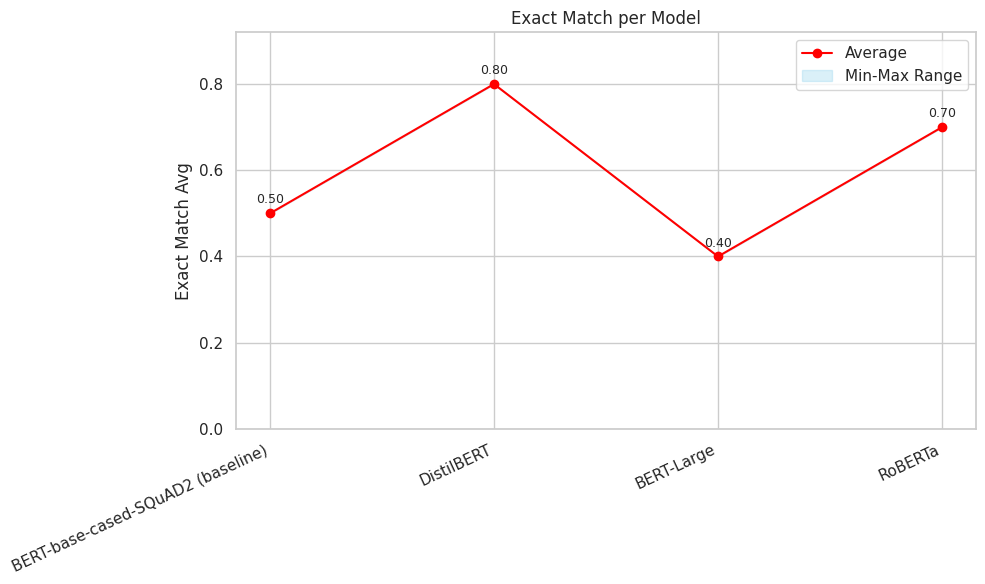

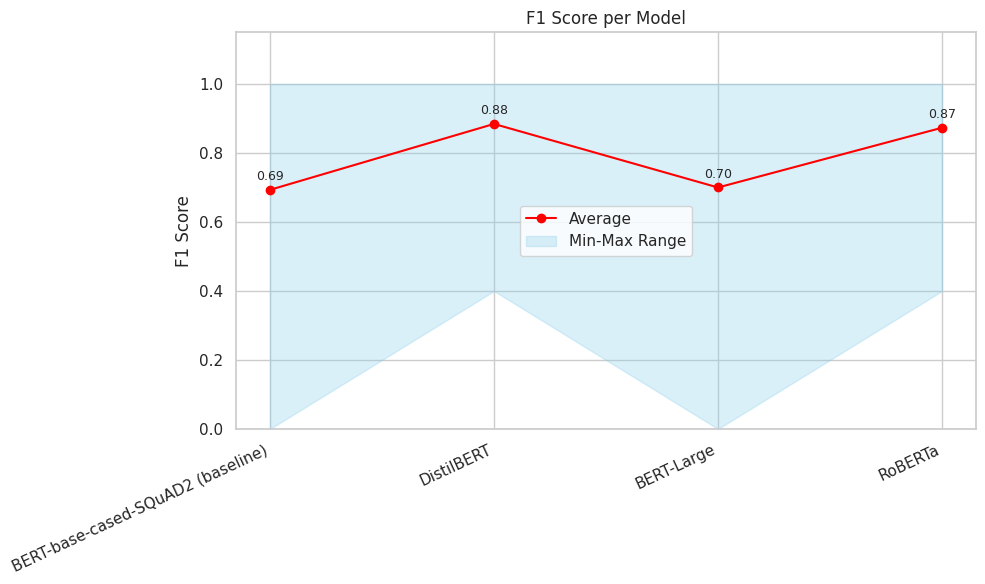

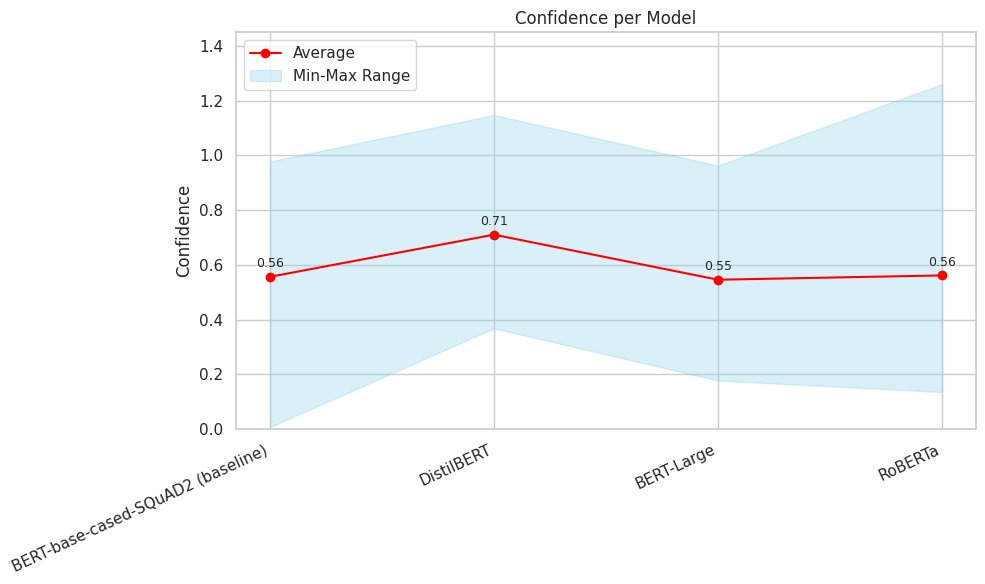

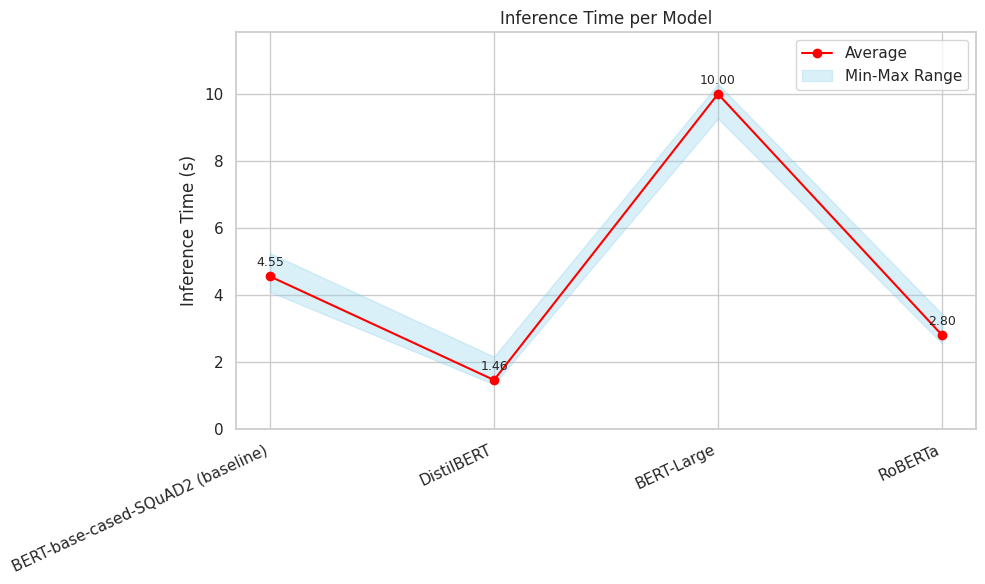

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


comparison_data = {
    "Model": [
        "BERT-base-cased-SQuAD2 (baseline)",
        "DistilBERT",
        "BERT-Large",
        "RoBERTa"
    ],
    "Exact Match Avg": [0.5, 0.8, 0.4, 0.7],
    "F1 Avg": [0.6933, 0.8844, 0.7001, 0.8734],
    "F1 Max": [1.0, 1.0, 1.0, 1.0],
    "F1 Min": [0.0, 0.4, 0.0, 0.4],
    "Confidence Avg": [0.5563, 0.7103, 0.5456, 0.5613],
    "Confidence Max": [0.978, 1.148, 0.963, 1.261],
    "Confidence Min": [0.007, 0.368, 0.177, 0.135],
    "Inference Time Avg (s)": [4.5531, 1.4598, 9.9985, 2.8008],
    "Inference Time Max (s)": [5.246, 2.157, 10.294, 3.430],
    "Inference Time Min (s)": [4.091, 1.333, 9.265, 2.558]
}

comparison_df = pd.DataFrame(comparison_data)

print("Comparison Table:")
display(comparison_df)


sns.set(style="whitegrid")

def plot_line_with_range(df, avg_col, min_col, max_col, title, ylabel):
    x = df['Model']
    y_avg = df[avg_col]
    y_min = df[min_col]
    y_max = df[max_col]

    plt.figure(figsize=(10,6))
    plt.plot(x, y_avg, marker='o', color='red', label='Average')
    plt.fill_between(x, y_min, y_max, color='skyblue', alpha=0.3, label='Min-Max Range')

    for i, val in enumerate(y_avg):
        plt.text(i, val+0.02*max(y_max), f"{val:.2f}", ha='center', va='bottom', fontsize=9)

    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=25, ha='right')
    plt.ylim(0, max(y_max)*1.15)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_line_with_range(comparison_df, "Exact Match Avg", "Exact Match Avg", "Exact Match Avg",
                     "Exact Match per Model", "Exact Match Avg")

plot_line_with_range(comparison_df, "F1 Avg", "F1 Min", "F1 Max",
                     "F1 Score per Model", "F1 Score")

plot_line_with_range(comparison_df, "Confidence Avg", "Confidence Min", "Confidence Max",
                     "Confidence per Model", "Confidence")

plot_line_with_range(comparison_df, "Inference Time Avg (s)", "Inference Time Min (s)", "Inference Time Max (s)",
                     "Inference Time per Model", "Inference Time (s)")


This code reviews four question-answering models by creating a pandas DataFrame that has average, minimum, and maximum for the measures of Exact Match, F1 Score, Confidence, and Inference Time. The DataFrame table is presented, and a plotting function produces line graphs that compare the averages, with shaded areas illustrating min-max ranges and the averages labeled. Each measure is plotted providing a clear visual and quantitative way to compare performance and variation of models in one workflow.

## ***Comparisons Interpretation***

When comparing the four models, there are clear trade-offs in speed, accuracy, and reliability. The `BERT-base-cased-SQuAD2` baseline elicited moderate performance according to the metrics; it achieved an average Exact Match (EM) score of 0.5 and an average F1 score of 0.6933, which suggests it sometimes had some issues in identifying the answer spans accurately, especially with subtle, multi-part questions. Confidence scores varied between 0.007 and 0.978, suggesting that there was some uncertainty on the part of the model to answer some questions. The average inference time was mid-range at 4.55 seconds.

`DistilBERT` was good for efficiency and accuracy, achieving the best averages in EM (0.8) and F1 (0.8844), with an average inference time that was remarkably quick (1.46 seconds). All this suggests that a distilled version of BERT can maintain much of BERT's predictive power while drastically reducing the computational burden.

`BERT-Large` had lower EM (0.4) but fairly strong F1 (0.7001) performance, showing sensitivity to precise span selection and some overfitting to SQuAD-style language. Its inference time was nearly 10 seconds, the slowest of the four models, which comes with the cost of model size.

The model with the best overall performance was `RoBERTa` with an EM of 0.7 and F1 of 0.8734. Its high accuracy and robustness to a variety of phrasing were a consequence of the model’s pretraining on a large collection. RoBERTa also performed better than BERT-Large, with an inference time of 2.8 seconds, but slower than DistilBERT.

Among all the BERT models that were observed, **`DistilBERT`** was the best overall because it had a good balance of high accuracy, consistent confidence, and low latency, while larger models such as BERT-Large had a good F1 in some cases, but were slower to respond and had lower exact match reliability. The model differences are impacted by architecture size, pretraining strategies, and span selection to answer the question. Response span selection is based on how likely the answer is to appear in the span given to the model and impacts EM score.